# CCT IRT



## 1. Imports e caminhos (`treino/`)


In [4]:
from pathlib import Path
import re

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

IRT_DIR = Path(r"C:\Users\User\Documents\Mestrado\UFPE\IRT")
TREINO_DIR = IRT_DIR / "treino"

CACHE_TEST = TREINO_DIR / "test_df.parquet"
CACHE_RESULTS = TREINO_DIR / "results_df.parquet"
CACHE_SPLIT_META = TREINO_DIR / "split_meta.joblib"

MODEL_NAMES = [
    "LogisticRegression",
    "SVC_Linear",
    "SGD_Logistic",
    "SVC_RBF",
    "GaussianNB",
    "RandomForest",
    "DecisionTree",
    "QDA",
]


def slug_raca(raca: str) -> str:
    return re.sub(r"[^\w.-]+", "_", str(raca).strip())


def path_modelo(raca: str, modelo: str) -> Path:
    return TREINO_DIR / slug_raca(raca) / f"{modelo}.joblib"


faltando = [p for p in (CACHE_TEST, CACHE_SPLIT_META) if not p.exists()]
if faltando:
    raise FileNotFoundError(
        "Artefatos ausentes em treino/. Rode irt_models_por_raca.ipynb primeiro:\n"
        + "\n".join(str(p) for p in faltando)
    )

print(f"Usando: {TREINO_DIR.resolve()}")


Usando: C:\Users\User\Documents\Mestrado\UFPE\IRT\treino


## 2. Filtrar o teste e montar a matriz

Altere **`BASE_TESTE`**: `"all"` ou uma raça (`"Black"`, `"White"`, …).

1. Carrega `treino/test_df.parquet` e filtra
2. Carrega os modelos de `treino/<raça>/`
3. Monta `matriz_prob` **só nas instâncias filtradas**


In [5]:
# >>> altere aqui <<<
BASE_TESTE = "Black"  # "all" | "White" | "Black" | "Asian-Pac-Islander" | "Amer-Indian-Eskimo" | "Other"


In [6]:
test_df_full = pd.read_parquet(CACHE_TEST)
split_meta = joblib.load(CACHE_SPLIT_META)
racas_validas = list(split_meta["racas_validas"])
feature_cols = list(split_meta["feature_cols"])

if BASE_TESTE == "all":
    test_df = test_df_full.copy()
    label_base = "todas as raças"
elif BASE_TESTE in racas_validas:
    test_df = test_df_full[test_df_full["race"] == BASE_TESTE].copy()
    label_base = f"raça = {BASE_TESTE}"
else:
    raise ValueError(f"BASE_TESTE={BASE_TESTE!r} inválida. Opções: 'all' ou {racas_validas}")

if len(test_df) < 2:
    raise ValueError(f"Base filtrada com poucas instâncias: {len(test_df)}")

# carrega modelos de treino/ (necessário só para montar a matriz filtrada)
pipes = {}
for race in racas_validas:
    for name in MODEL_NAMES:
        p = path_modelo(race, name)
        if not p.exists():
            raise FileNotFoundError(f"Modelo ausente: {p}")
        pipes[(race, name)] = joblib.load(p)


def construir_matriz_probabilidades(instancias_df):
    X = instancias_df[feature_cols]
    linhas, indices = [], []
    for raca in sorted(racas_validas):
        for modelo in MODEL_NAMES:
            linhas.append(pipes[(raca, modelo)].predict_proba(X)[:, 1])
            indices.append(f"{modelo}@{raca}")
    return pd.DataFrame(linhas, index=indices, columns=instancias_df.index).round(3)


matriz_prob = construir_matriz_probabilidades(test_df)
meta_instancias = test_df[["race", "_target"]].rename(columns={"_target": "y_positivo"})
results_df = pd.read_parquet(CACHE_RESULTS) if CACHE_RESULTS.exists() else None

print(f"Base: {label_base} — {len(test_df)} instâncias (de {len(test_df_full)})")
print(f"matriz_prob: {matriz_prob.shape[0]} itens × {matriz_prob.shape[1]} instâncias")
print(f"pipes: {len(pipes)}")
display(test_df["race"].value_counts().rename("n"))
display(matriz_prob.iloc[:5, :5])
display(meta_instancias.head())


Base: raça = Black — 313 instâncias (de 3257)
matriz_prob: 40 itens × 313 instâncias
pipes: 40


race
Black    313
Name: n, dtype: int64

,2232,28247,15736,12527,124
LogisticRegression@Amer-Indian-Eskimo,0.011,0.015,0.407,0.006,0.004
SVC_Linear@Amer-Indian-Eskimo,0.045,0.019,0.511,0.008,0.018
SGD_Logistic@Amer-Indian-Eskimo,0.000,0.000,1.000,0.000,0.000
SVC_RBF@Amer-Indian-Eskimo,0.028,0.023,0.301,0.022,0.031
GaussianNB@Amer-Indian-Eskimo,1.000,0.000,1.000,0.000,0.000


,race,y_positivo
2232,Black,0
28247,Black,0
15736,Black,0
12527,Black,0
124,Black,0


In [7]:
test_df

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,_target
2232,45,Private,339506,HS-grad,9,Never-married,Sales,Not-in-family,Black,Male,0,0,40,United-States,<=50K,0
28247,47,Private,264244,HS-grad,9,Married-spouse-absent,Craft-repair,Not-in-family,Black,Female,0,0,40,United-States,<=50K,0
15736,33,Federal-gov,615893,Masters,14,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,Nicaragua,<=50K,0
12527,48,Private,167967,HS-grad,9,Separated,Machine-op-inspct,Unmarried,Black,Female,0,0,40,United-States,<=50K,0
124,19,Private,301606,Some-college,10,Never-married,Other-service,Own-child,Black,Male,0,0,35,United-States,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1555,44,Private,139338,12th,8,Divorced,Transport-moving,Unmarried,Black,Male,0,0,40,United-States,<=50K,0
1952,30,Private,226013,Bachelors,13,Never-married,Prof-specialty,Not-in-family,Black,Male,0,0,40,United-States,<=50K,0
25326,43,Private,200734,HS-grad,9,Separated,Other-service,Not-in-family,Black,Female,0,0,40,United-States,<=50K,0
3650,18,Private,104704,HS-grad,9,Never-married,Adm-clerical,Own-child,Black,Male,0,0,40,United-States,<=50K,0


In [8]:
matriz_prob


,2232,28247,15736,12527,124,8349,14278,18515,14105,7209,...,14586,3889,15312,15479,31334,1555,1952,25326,3650,25882
LogisticRegression@Amer-Indian-Eskimo,0.011,0.015,0.407,0.006,0.004,0.040,0.013,0.004,0.036,0.009,...,0.084,0.086,0.010,0.001,0.006,0.033,0.160,0.009,0.015,0.117
SVC_Linear@Amer-Indian-Eskimo,0.045,0.019,0.511,0.008,0.018,0.065,0.031,0.015,0.041,0.022,...,0.066,0.099,0.060,0.005,0.007,0.056,0.207,0.011,0.033,0.086
SGD_Logistic@Amer-Indian-Eskimo,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
SVC_RBF@Amer-Indian-Eskimo,0.028,0.023,0.301,0.022,0.031,0.032,0.020,0.019,0.035,0.036,...,0.130,0.042,0.025,0.027,0.035,0.071,0.078,0.018,0.043,0.072
GaussianNB@Amer-Indian-Eskimo,1.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,...,1.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
RandomForest@Amer-Indian-Eskimo,0.025,0.030,0.425,0.005,0.000,0.115,0.015,0.000,0.185,0.005,...,0.310,0.090,0.025,0.000,0.015,0.025,0.305,0.005,0.015,0.195
DecisionTree@Amer-Indian-Eskimo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
QDA@Amer-Indian-Eskimo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
LogisticRegression@Asian-Pac-Islander,0.045,0.078,0.453,0.132,0.011,0.015,0.039,0.014,0.334,0.038,...,0.697,0.500,0.012,0.010,0.206,0.044,0.120,0.079,0.015,0.345
SVC_Linear@Asian-Pac-Islander,0.054,0.089,0.428,0.090,0.032,0.023,0.069,0.037,0.220,0.067,...,0.660,0.461,0.030,0.024,0.196,0.064,0.176,0.084,0.042,0.299


In [9]:
# Conferência do filtro
print(f"BASE_TESTE = {BASE_TESTE!r} | n = {len(test_df)} | matriz = {matriz_prob.shape}")


BASE_TESTE = 'Black' | n = 313 | matriz = (40, 313)


## 3. Modelo CCT contínuo

Usa `matriz_prob` (itens = `modelo@raça`) e os rótulos reais em `meta_instancias`.
Cada linha é um respondente CCT; cada coluna, uma instância de teste.


In [10]:
import pymc as pm
import pytensor.tensor as pt

#def train_continuous_model_sc_v3(responses: pd.DataFrame):
def train_continuous_model_sc_v3(responses: pd.DataFrame,
                           draws: int=500, tune: int=50, chains: int=1, target_accept: float=0.9):
    y = responses.to_numpy(dtype=float)
    I, J = y.shape

    eps = 1e-6

    y = np.clip(y, eps, 1 - eps)
    resp_logits = np.log(y / (1 - y))

    prior_mu = resp_logits.mean(axis=0)

    sample_var = resp_logits.var(axis=0) + 1e-3
    tau_init = 1.0 / sample_var

    with pm.Model() as model:

        # 1. Verdade cultural por cultura e item

        # tau_item =  "tau_item", alpha=1, beta=1, shape=(1,J))

        tau_item = pm.Gamma("tau_item",alpha=2,beta=2 / tau_init,shape= (1,J))

        truth_logits = pm.Normal(
            "truth_logits",
            mu=prior_mu,
            tau = tau_item,
            shape=(1, J),
        )

        # 2. Parametros do respondente

        prior_mu_resp = resp_logits.mean(axis=1, keepdims=True)
        prior_sigma_resp = resp_logits.std(axis=1, keepdims=True) + 1e-3

        # mu = 0 ou prior_mu_resp
        # bias = pm.Normal("bias", mu=0, sigma=1, shape=(I, 1))
        bias = pm.Normal("bias", mu=prior_mu_resp, sigma=prior_sigma_resp, shape=(I, 1))

        discrimination = pm.LogNormal("discrimination", mu=0, sigma= 0.5, shape=(I, 1))

        # 3. Como resposta esperada depende dos parametros de items e respondentes

        pred_mu = discrimination * truth_logits + bias

        obs = pm.Normal(
            "obs",
            mu=pred_mu,
            tau = tau_item/(discrimination**2), # repondent tau

            observed=resp_logits
        )

        trace = pm.sample(
            draws=draws, tune=tune, chains=chains, target_accept=target_accept, seed = 42
        )

    return trace


In [11]:
def save_cct_params(trace, responses,y_test):
    # 1. averaging the parameters across chains and draws
    discr_all = trace.posterior["discrimination"].stack(samples=("chain", "draw"))
    bias_all = trace.posterior["bias"].stack(samples=("chain", "draw"))

    disc = discr_all.mean(dim="samples").values
    bias = bias_all.mean(dim="samples").values

    bias_p = 1/(1 + np.exp(-bias.flatten())) # in the [0,1] scale

    # saving the tau paramenter for respondents --- for model 2
    tau_all_item = trace.posterior["tau_item"].stack(samples=("chain", "draw"))
    tau_item = tau_all_item.mean(dim="samples").values
    desv_item = 1/(1 + np.exp(-np.sqrt(1/tau_item.flatten())))  # computing the sd in the [0,1] scale

    #3.  saving the estimated truth
    truths = trace.posterior["truth_logits"].stack(samples=("chain", "draw"))
    truth = truths.mean(dim="samples").values

    # applying the transformation on the logits to have the estimated probabilities
    true_p = 1/(1 + np.exp(-truth.flatten()))

    df_cct_params = pd.DataFrame({
        'Discrimination': disc.flatten(),
        'Bias_l': bias.flatten(),
        'Bias_p': bias_p.flatten(),
        #'Tau_resp': tau_resp.flatten(),
        #'Desv_l': np.sqrt(1/tau_resp.flatten()),
        #'Desv_p': desv_resp.flatten()
    }, index=responses.index)

    mse = list()  # square error of responses relative to the estimated truth
    mse_rcc = list() # square error of responses relative to the estimated rcc (expected model response)

    for i in range(len(responses)): # Iterate over all models in responses
      resp = responses.iloc[i]

      ai = disc[i]
      Bi = bias_p[i]

      pij = 1 / (1 + (Bi/(1-Bi))*(true_p/(1-true_p))**(-ai))

      mse.append(np.mean((resp -true_p)**2))
      mse_rcc.append(np.mean((resp - pij)**2))

    df_cct_params['MSE'] = mse
    df_cct_params['MSE_RCC'] = mse_rcc

    from sklearn.metrics import brier_score_loss

    brier_scores = []
    for i in range(len(responses)):
        model_response = responses.iloc[i]
        bs = brier_score_loss(y_test, model_response)
        brier_scores.append(bs)

    df_cct_params['Brier_Score'] = brier_scores

    df_item_params = pd.DataFrame({
    'Truths': true_p,
    'Truths_l': truth.flatten(),
    'Desv_l': np.sqrt(1/tau_item.flatten()),
    'Tau_item': tau_item.flatten(),
    'Desv_item': desv_item.flatten(),
    'Average_Response': responses.mean(axis=0).values,
    'True_Label': y_test
    })

    # print(df_cct_params.round(3))

    return df_cct_params, df_item_params



In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ICC(bi,ai,p,resp,label):
    eps = 1e-6

    # k values in (0,1)
    pj = np.linspace(0.001, 0.999, 1000)

    # Compute p
    pj = np.clip(pj, eps, 1 - eps)
    pj_l = np.log(pj / (1 - pj))

    pij_l = ai * pj_l + bi

    pij = 1 / (1 + np.exp(-pij_l))

    resp_l = np.log(resp/(1-resp))
    p_l = np.log(p/(1-p))

    # Compute p
    # Plot


    plt.figure(figsize=(14, 5))

    # Subplot 1: Two Moons Dataset
    plt.subplot(1, 2, 1)
    plt.ylim(0, 1.1)
    plt.xlim(-6, 6)
    plt.plot(pj_l, pij, linewidth=2)
    plt.scatter(p_l, resp)

    plt.xlabel("Instance Logit")
    plt.ylabel("Model Probability")
    plt.title(f"Model {label} --- Discr = {ai.item():.2f}, Logit Bias = {bi.item():.2f}")
    plt.grid(True)

    plt.subplot(1, 2, 2)

    plt.ylim(0, 1.1)
    plt.plot(pj, pij, linewidth=2)

    plt.scatter(p, resp)

    plt.xlabel("Instance Probability")
    plt.ylabel("Model Probability")
    plt.title(f"Model {label} --- Discr = {ai.item():.2f}, Bias = {1 / (1 + np.exp(-bi.item())):.2f}")
    plt.grid(True)

    plt.tight_layout()
    plt.show()




## Running CCT Model

In [13]:
matriz_prob

,2232,28247,15736,12527,124,8349,14278,18515,14105,7209,...,14586,3889,15312,15479,31334,1555,1952,25326,3650,25882
LogisticRegression@Amer-Indian-Eskimo,0.011,0.015,0.407,0.006,0.004,0.040,0.013,0.004,0.036,0.009,...,0.084,0.086,0.010,0.001,0.006,0.033,0.160,0.009,0.015,0.117
SVC_Linear@Amer-Indian-Eskimo,0.045,0.019,0.511,0.008,0.018,0.065,0.031,0.015,0.041,0.022,...,0.066,0.099,0.060,0.005,0.007,0.056,0.207,0.011,0.033,0.086
SGD_Logistic@Amer-Indian-Eskimo,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
SVC_RBF@Amer-Indian-Eskimo,0.028,0.023,0.301,0.022,0.031,0.032,0.020,0.019,0.035,0.036,...,0.130,0.042,0.025,0.027,0.035,0.071,0.078,0.018,0.043,0.072
GaussianNB@Amer-Indian-Eskimo,1.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000,...,1.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,1.000
RandomForest@Amer-Indian-Eskimo,0.025,0.030,0.425,0.005,0.000,0.115,0.015,0.000,0.185,0.005,...,0.310,0.090,0.025,0.000,0.015,0.025,0.305,0.005,0.015,0.195
DecisionTree@Amer-Indian-Eskimo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
QDA@Amer-Indian-Eskimo,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
LogisticRegression@Asian-Pac-Islander,0.045,0.078,0.453,0.132,0.011,0.015,0.039,0.014,0.334,0.038,...,0.697,0.500,0.012,0.010,0.206,0.044,0.120,0.079,0.015,0.345
SVC_Linear@Asian-Pac-Islander,0.054,0.089,0.428,0.090,0.032,0.023,0.069,0.037,0.220,0.067,...,0.660,0.461,0.030,0.024,0.196,0.064,0.176,0.084,0.042,0.299


In [14]:
# responses: itens (modelo@raça) × instâncias — já no formato do CCT
responses = matriz_prob.copy()
y_test = meta_instancias.loc[responses.columns, "y_positivo"].to_numpy()

print(f"responses: {responses.shape[0]} modelos × {responses.shape[1]} instâncias")
print(f"itens (amostra): {responses.index[:5].tolist()}")
print(f"y_test: {len(y_test)} | positivos: {int(y_test.sum())}")

responses: 40 modelos × 313 instâncias
itens (amostra): ['LogisticRegression@Amer-Indian-Eskimo', 'SVC_Linear@Amer-Indian-Eskimo', 'SGD_Logistic@Amer-Indian-Eskimo', 'SVC_RBF@Amer-Indian-Eskimo', 'GaussianNB@Amer-Indian-Eskimo']
y_test: 313 | positivos: 30


In [15]:
trace = train_continuous_model_sc_v3(
    responses, draws=100, tune=10, chains=1, target_accept=0.9
)
df_cct_params, df_item_params = save_cct_params(trace, responses, y_test)

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [tau_item, truth_logits, bias, discrimination]


Output()

Sampling 1 chain for 10 tune and 100 draw iterations (10 + 100 draws total) took 0 seconds.
There were 100 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [16]:
df_to_print = df_cct_params.loc[:, ['Discrimination','Bias_l','MSE_RCC','MSE','Brier_Score']]

columns_order_display = [
    'Discrimination',
    'Bias_l',
    'MSE_RCC',
    'MSE',
    'Brier_Score'
]
df_to_print = df_to_print[columns_order_display]
print(df_to_print.round(3))

                                       Discrimination  Bias_l  MSE_RCC    MSE  \
LogisticRegression@Amer-Indian-Eskimo           0.200  -3.227    0.684  0.024   
SVC_Linear@Amer-Indian-Eskimo                   0.149  -2.517    0.592  0.025   
SGD_Logistic@Amer-Indian-Eskimo                 0.358 -11.033    0.932  0.058   
SVC_RBF@Amer-Indian-Eskimo                      0.106  -2.495    0.634  0.028   
GaussianNB@Amer-Indian-Eskimo                   1.936   2.111    0.387  0.340   
RandomForest@Amer-Indian-Eskimo                 0.593  -0.561    0.030  0.024   
DecisionTree@Amer-Indian-Eskimo                 0.872  -6.737    0.581  0.093   
QDA@Amer-Indian-Eskimo                          0.124 -13.001    0.964  0.040   
LogisticRegression@Asian-Pac-Islander           0.168  -1.802    0.328  0.018   
SVC_Linear@Asian-Pac-Islander                   0.123  -1.680    0.343  0.021   
SGD_Logistic@Asian-Pac-Islander                 0.290  -1.723    0.209  0.030   
SVC_RBF@Asian-Pac-Islander  

Modelos Black: 8
                          Discrimination  Bias_l  MSE_RCC    MSE  Brier_Score
LogisticRegression@Black           0.261  -3.162    0.557  0.012        0.054
SVC_Linear@Black                   0.204  -2.825    0.557  0.012        0.055
SGD_Logistic@Black                 0.573  -2.793    0.192  0.009        0.055
SVC_RBF@Black                      0.129  -2.787    0.634  0.011        0.056
GaussianNB@Black                   1.728  11.132    0.714  0.603        0.640
RandomForest@Black                 0.921  -2.114    0.036  0.017        0.053
DecisionTree@Black                 0.808  -7.424    0.672  0.062        0.105
QDA@Black                          0.030 -13.630    0.979  0.039        0.077


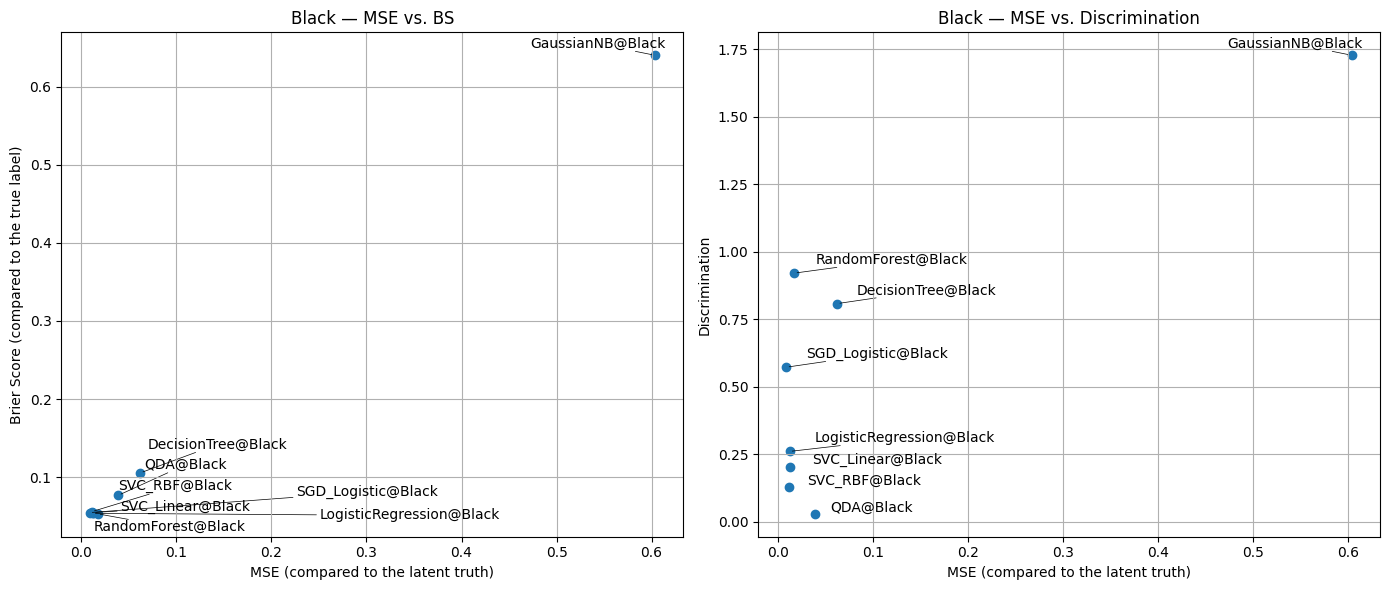

In [17]:
from adjustText import adjust_text


# df_cct_params_black = df_cct_params[
#     df_cct_params.index.str.endswith("@Black")
# ].copy()

racas = ["Black"]
df_cct_params_cmp = df_cct_params[
    df_cct_params.index.to_series().str.split("@").str[-1].isin(racas)
].copy()

df_black_print = df_cct_params_cmp.loc[
    :, ["Discrimination", "Bias_l", "MSE_RCC", "MSE", "Brier_Score"]
]
print(f"Modelos Black: {len(df_cct_params_cmp)}")
print(df_black_print.round(3))


brier = df_cct_params_cmp["Brier_Score"]
MSE = df_cct_params_cmp["MSE"]
discr = df_cct_params_cmp["Discrimination"]
model_names_black = df_cct_params_cmp.index

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MSE vs Brier Score
axes[0].scatter(MSE, brier)
axes[0].set_xlabel("MSE (compared to the latent truth)")
axes[0].set_ylabel("Brier Score (compared to the true label)")
axes[0].set_title("Black — MSE vs. BS")
axes[0].grid(True)
texts0 = [
    axes[0].text(MSE.iloc[i], brier.iloc[i], name, ha="left", va="bottom")
    for i, name in enumerate(model_names_black)
]
adjust_text(texts0, ax=axes[0], arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

# Discrimination vs MSE
axes[1].scatter(MSE, discr)
axes[1].set_xlabel("MSE (compared to the latent truth)")
axes[1].set_ylabel("Discrimination")
axes[1].set_title("Black — MSE vs. Discrimination")
axes[1].grid(True)
texts1 = [
    axes[1].text(MSE.iloc[i], discr.iloc[i], name, ha="left", va="bottom")
    for i, name in enumerate(model_names_black)
]
adjust_text(texts1, ax=axes[1], arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

plt.tight_layout()
plt.show()


Modelos (todas as raças): 40
                                       Discrimination  Bias_l  MSE_RCC    MSE  \
LogisticRegression@Amer-Indian-Eskimo           0.200  -3.227    0.684  0.024   
SVC_Linear@Amer-Indian-Eskimo                   0.149  -2.517    0.592  0.025   
SGD_Logistic@Amer-Indian-Eskimo                 0.358 -11.033    0.932  0.058   
SVC_RBF@Amer-Indian-Eskimo                      0.106  -2.495    0.634  0.028   
GaussianNB@Amer-Indian-Eskimo                   1.936   2.111    0.387  0.340   
RandomForest@Amer-Indian-Eskimo                 0.593  -0.561    0.030  0.024   
DecisionTree@Amer-Indian-Eskimo                 0.872  -6.737    0.581  0.093   
QDA@Amer-Indian-Eskimo                          0.124 -13.001    0.964  0.040   
LogisticRegression@Asian-Pac-Islander           0.168  -1.802    0.328  0.018   
SVC_Linear@Asian-Pac-Islander                   0.123  -1.680    0.343  0.021   
SGD_Logistic@Asian-Pac-Islander                 0.290  -1.723    0.209  0.030   

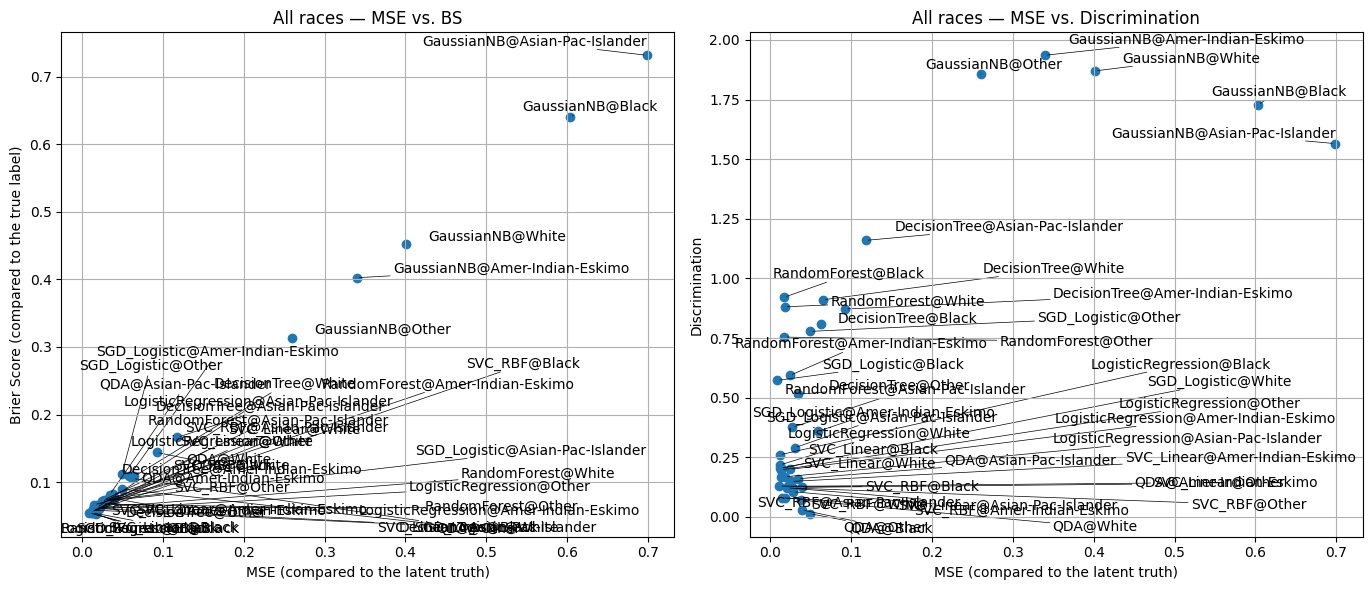

In [21]:
from adjustText import adjust_text

# Todos os modelos (todas as raças)
df_all_print = df_cct_params.loc[
    :, ["Discrimination", "Bias_l", "MSE_RCC", "MSE", "Brier_Score"]
]
print(f"Modelos (todas as raças): {len(df_cct_params)}")
print(df_all_print.round(3))

brier_all = df_cct_params["Brier_Score"]
MSE_all = df_cct_params["MSE"]
discr_all = df_cct_params["Discrimination"]
model_names_all = df_cct_params.index

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MSE vs Brier Score
axes[0].scatter(MSE_all, brier_all)
axes[0].set_xlabel("MSE (compared to the latent truth)")
axes[0].set_ylabel("Brier Score (compared to the true label)")
axes[0].set_title("All races — MSE vs. BS")
axes[0].grid(True)
texts0 = [
    axes[0].text(MSE_all.iloc[i], brier_all.iloc[i], name, ha="left", va="bottom")
    for i, name in enumerate(model_names_all)
]
adjust_text(texts0, ax=axes[0], arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

# Discrimination vs MSE
axes[1].scatter(MSE_all, discr_all)
axes[1].set_xlabel("MSE (compared to the latent truth)")
axes[1].set_ylabel("Discrimination")
axes[1].set_title("All races — MSE vs. Discrimination")
axes[1].grid(True)
texts1 = [
    axes[1].text(MSE_all.iloc[i], discr_all.iloc[i], name, ha="left", va="bottom")
    for i, name in enumerate(model_names_all)
]
adjust_text(texts1, ax=axes[1], arrowprops=dict(arrowstyle="-", color="black", lw=0.5))

plt.tight_layout()
plt.show()


-3.1618596803011267
Discrimination    0.260736
Bias_l           -3.161860
Bias_p            0.040627
MSE               0.011947
MSE_RCC           0.556512
Brier_Score       0.053629
Name: LogisticRegression@Black, dtype: float64


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


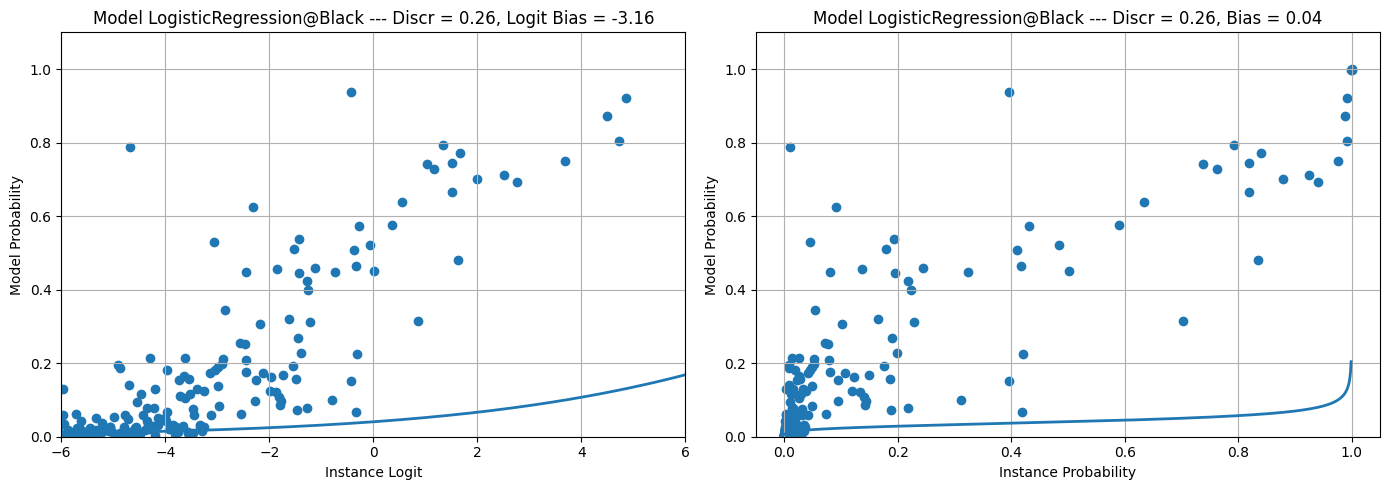

In [18]:
model_names = responses.index.tolist()
model_name = "LogisticRegression@Black"

if model_name in df_cct_params.index:
    model_params = df_cct_params.loc[model_name, ["Discrimination", "Bias_l", "Bias_p"]]
else:
    print(f"Model '{model_name}' not found in the cct parameters DataFrame.")
    print("Available models are:", df_cct_params.index.tolist())

a = model_params["Discrimination"]
B = model_params["Bias_l"]
print(B)
resp = responses.loc[model_name]
true_p = df_item_params["Truths"]

print(df_cct_params.loc[model_name])

plot_ICC(B, a, true_p, resp, model_name)



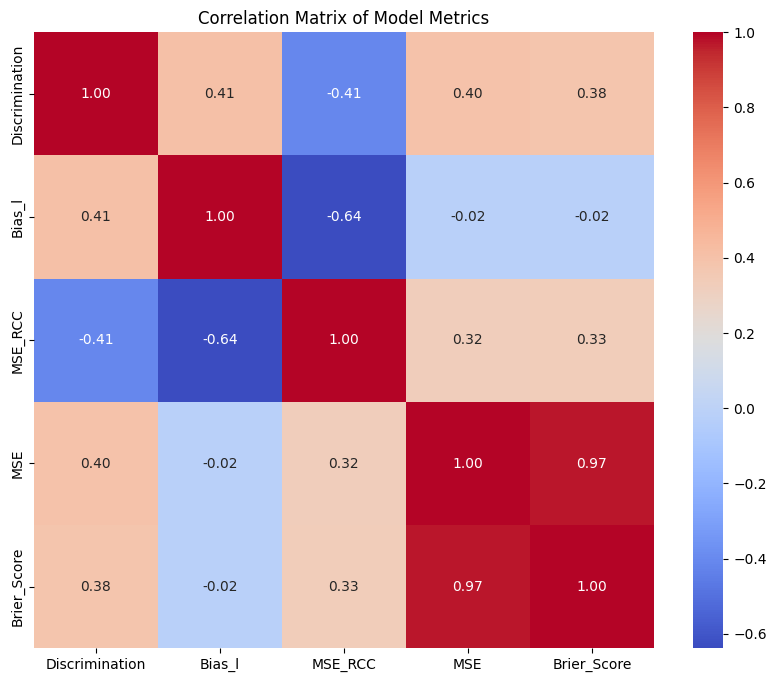

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

params = df_cct_params.loc[:, ['Discrimination','Bias_l','MSE_RCC','MSE','Brier_Score']]

#correlation_matrix = df_cct_params.corr()
correlation_matrix = params.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Model Metrics')
plt.show()

Modelos Black na correlação: 8


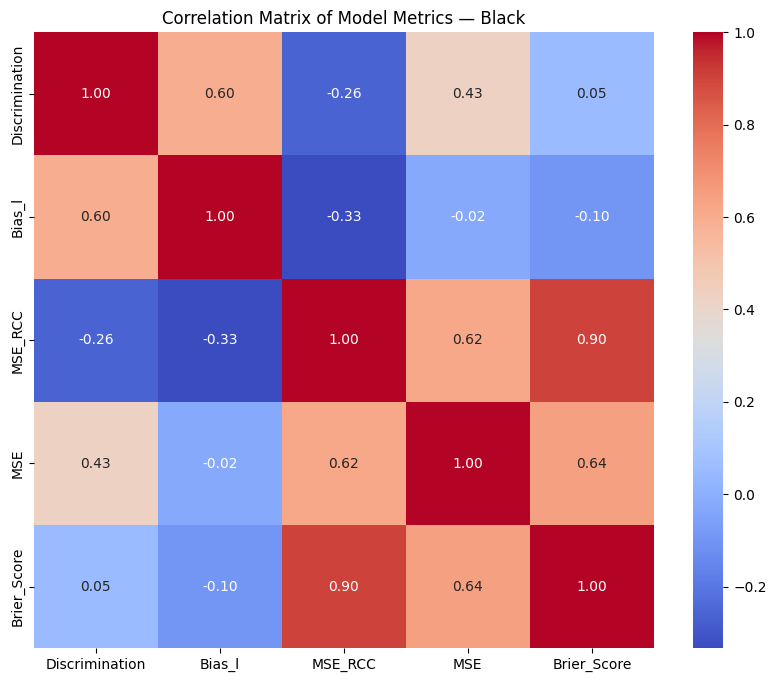

In [20]:
# Matriz de correlação — apenas modelos da raça Black
params_black = df_cct_params[
    df_cct_params.index.str.endswith("@Black")
].loc[:, ["Discrimination", "Bias_l", "MSE_RCC", "MSE", "Brier_Score"]]

print(f"Modelos Black na correlação: {len(params_black)}")
correlation_matrix_black = params_black.corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_black, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Model Metrics — Black")
plt.show()
